In [1]:
from pathlib import Path
import os
import json
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
from torch.utils.data import DataLoader

from train_utils import get_info
from model import DiagnosticModel
from data import DicomDataset

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# DataFrame Metrics

In [2]:
folders = [Path("../outputs4")]

In [3]:
all_experiments = []

for base in folders:
    for exp_name in os.listdir(base):
        exp_path = base / exp_name
        if not exp_path.is_dir():
            continue

        params_path  = exp_path / "params.json"

        for run_name in os.listdir(exp_path):
            run_path = exp_path / run_name
            if not run_path.is_dir():
                continue

            # model_path   = run_path / "best_model.pth"
            results_path = run_path / "test_results.json"

            if not results_path.exists():
                continue

            with open(params_path, "r") as f:
                params = json.load(f)

            with open(results_path, "r") as f:
                results = json.load(f)

            entry = {
                "exp": exp_name,
                "run": run_name,
                "auc": float(results["auc"]),
            }

            # Add confusion-matrix-derived metrics
            for k, v in get_info(np.array(results["val_cfvalues"])).items():
                entry[k] = v

            all_experiments.append(entry)


In [4]:
df = pd.DataFrame(all_experiments)

# Convert the meta columns into index
df = df.set_index(["exp", "run"]).sort_index()
df


auc        tn        fp        fn        tp  \
exp                    run                                                      
b_mm                   run0  0.879891  0.898693  0.003268  0.068627  0.029412   
                       run1  0.801464  0.852941  0.049020  0.058824  0.039216   
                       run2  0.789085  0.861111  0.040850  0.058824  0.039216   
                       run3  0.843524  0.879085  0.022876  0.058824  0.039216   
                       run4  0.778638  0.885621  0.016340  0.062092  0.035948   
b_mm_mask_norm         run0  0.853537  0.884135  0.030303  0.055258  0.030303   
                       run1  0.864076  0.885918  0.028520  0.049911  0.035651   
                       run2  0.860136  0.898396  0.016043  0.055258  0.030303   
                       run3  0.880117  0.907308  0.007130  0.057041  0.028520   
                       run4  0.804662  0.885918  0.028520  0.055258  0.030303   
b_mm_mask_norm_perc_02 run0  0.832846  0.901961  0.012478  0.048128  0.037433   
                       run1  0.820500  0.891266  0.023173  0.053476  0.032086   
                       run2  0.819120  0.877005  0.037433  0.058824  0.026738   
                       run3  0.801718  0.893048  0.021390  0.053476  0.032086   
                       run4  0.852684  0.880570  0.033868  0.048128  0.037433   

                                  tpr       fpr      prec    recall        f1  \
exp                    run                                                      
b_mm                   run0  0.300000  0.003623  0.900000  0.300000  0.450000   
                       run1  0.400000  0.054348  0.444444  0.400000  0.421053   
                       run2  0.400000  0.045290  0.489796  0.400000  0.440367   
                       run3  0.400000  0.025362  0.631579  0.400000  0.489796   
                       run4  0.366667  0.018116  0.687500  0.366667  0.478261   
b_mm_mask_norm         run0  0.354167  0.033138  0.500000  0.354167  0.414634   
                       run1  0.416667  0.031189  0.555556  0.416667  0.476190   
                       run2  0.354167  0.017544  0.653846  0.354167  0.459459   
                       run3  0.333333  0.007797  0.800000  0.333333  0.470588   
                       run4  0.354167  0.031189  0.515152  0.354167  0.419753   
b_mm_mask_norm_perc_02 run0  0.437500  0.013645  0.750000  0.437500  0.552632   
                       run1  0.375000  0.025341  0.580645  0.375000  0.455696   
                       run2  0.312500  0.040936  0.416667  0.312500  0.357143   
                       run3  0.375000  0.023392  0.600000  0.375000  0.461538   
                       run4  0.437500  0.037037  0.525000  0.437500  0.477273   

                                  acc  
exp                    run             
b_mm                   run0  0.928105  
                       run1  0.892157  
                       run2  0.900327  
                       run3  0.918301  
                       run4  0.921569  
b_mm_mask_norm         run0  0.914439  
                       run1  0.921569  
                       run2  0.928699  
                       run3  0.935829  
                       run4  0.916221  
b_mm_mask_norm_perc_02 run0  0.939394  
                       run1  0.923351  
                       run2  0.903743  
                       run3  0.925134  
                       run4  0.918004

In [5]:
exp_avg = df.groupby("exp").mean()
exp_avg

,auc,tn,fp,fn,tp,tpr,fpr,prec,recall,f1,acc
exp,,,,,,,,,,,
b_mm,0.818521,0.875490,0.026471,0.061438,0.036601,0.373333,0.029348,0.630664,0.373333,0.455895,0.912092
b_mm_mask_norm,0.852506,0.892335,0.022103,0.054545,0.031016,0.362500,0.024172,0.604911,0.362500,0.448125,0.923351
b_mm_mask_norm_perc_02,0.825374,0.888770,0.025668,0.052406,0.033155,0.387500,0.028070,0.574462,0.387500,0.460856,0.921925


# Sort Model Results

## Get Model

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [7]:
best_model_path = Path('../outputs4/b_mm_mask_norm/run3/best_model.pth')
model = DiagnosticModel(model_name = 'resnet50', include_weights = False, in_channels = 3)

checkpoint = torch.load(best_model_path, map_location=next(model.parameters()).device)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

DiagnosticModel(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
    

## Get Data

In [64]:
max_samples = None
data_dir = Path('/data/vision/polina/users/marcusbl/data')
dataset = DicomDataset(data_dir, max_samples = max_samples)
dataset.set_norm(norm_method = 'min-max', masked_norm = True, perc_norm = 0.02)

batch_size = 16
dataloader = DataLoader(dataset, shuffle = False, batch_size = batch_size)

Loading People Data: 100%|██████████| 30/30 [00:00<00:00, 57.46it/s]


##  Run the Model on Data (~2 min on cuda)

In [65]:
results = {
    "conf": [],
    "idx": [],
    "pred": [],
    "true": [],
} 

for idx, (data, labels) in enumerate(tqdm(dataloader)):
    data, labels = data.to(device), labels.to(device)
    outputs = model(data) # (B, 2)

    probs = torch.softmax(outputs, dim=1)               # (B, 2)
    _, preds = torch.max(outputs, dim=1)                # preds is (B)

    conf = probs[torch.arange(len(probs)), preds]       # confidence per sample = probability of prediciting that prediction

    results['conf'].extend(conf.tolist())
    results['idx'].extend([int(idx * batch_size + i) for i in range(len(labels))])
    results['pred'].extend(preds.tolist())
    results['true'].extend(labels.tolist())

results_df = pd.DataFrame(results)

100%|██████████| 458/458 [01:52<00:00,  4.07it/s]


## Display results by confidence 

In [75]:
incorrect_mask = results_df['pred'] != results_df['true']
incorrect_df = results_df[incorrect_mask]

In [76]:
def display_incorrect(incorrect_df: pd.DataFrame, dataset: DicomDataset, max_display: int=10):
    """
    Shows incorrect predictions with:
      - True label (top-left)
      - Predicted label (top-right)
      - Confidence (bottom-center)
    """
    incorrect_df = incorrect_df.sort_values(by='conf', ascending=False).reset_index(drop=True)
    
    # Set up Display
    num_display = min(len(incorrect_df), max_display)
    nrows = int(np.sqrt(num_display))
    ncols = int(num_display / nrows)

    # Taller figure: width fixed, height scales with number
    fig, axes = plt.subplots(
        nrows=nrows, 
        ncols=ncols, 
        figsize=(4 * nrows, 4 * ncols),
        squeeze=False
    )

    for i in range(nrows):
        for j in range(ncols):
            df_row_idx = i * nrows + j
            ax = axes[i, j]

            # Extract index and metadata
            df_row = incorrect_df.iloc[df_row_idx]
            display_idx = int(df_row['idx'])
            pred = df_row['pred']
            true = df_row['true']
            conf = df_row['conf']

            # Image extraction (assuming (img, label) format)
            img = dataset[display_idx][0][0]

            # Show image
            ax.imshow(img, cmap="gray")
            ax.axis("off")

            # Annotation text
            title = f"True: {true} | Pred: {pred} (Idx {display_idx})"
            if conf is not None:
                subtitle = f"Confidence: {conf:.3f}"
            else:
                subtitle = ""

            ax.set_title(title, fontsize=14, pad=10)
            ax.text(
                0.5, -0.12, subtitle,
                transform=ax.transAxes,
                ha="center", va="top",
                fontsize=12
            )

    plt.tight_layout()
    plt.show()


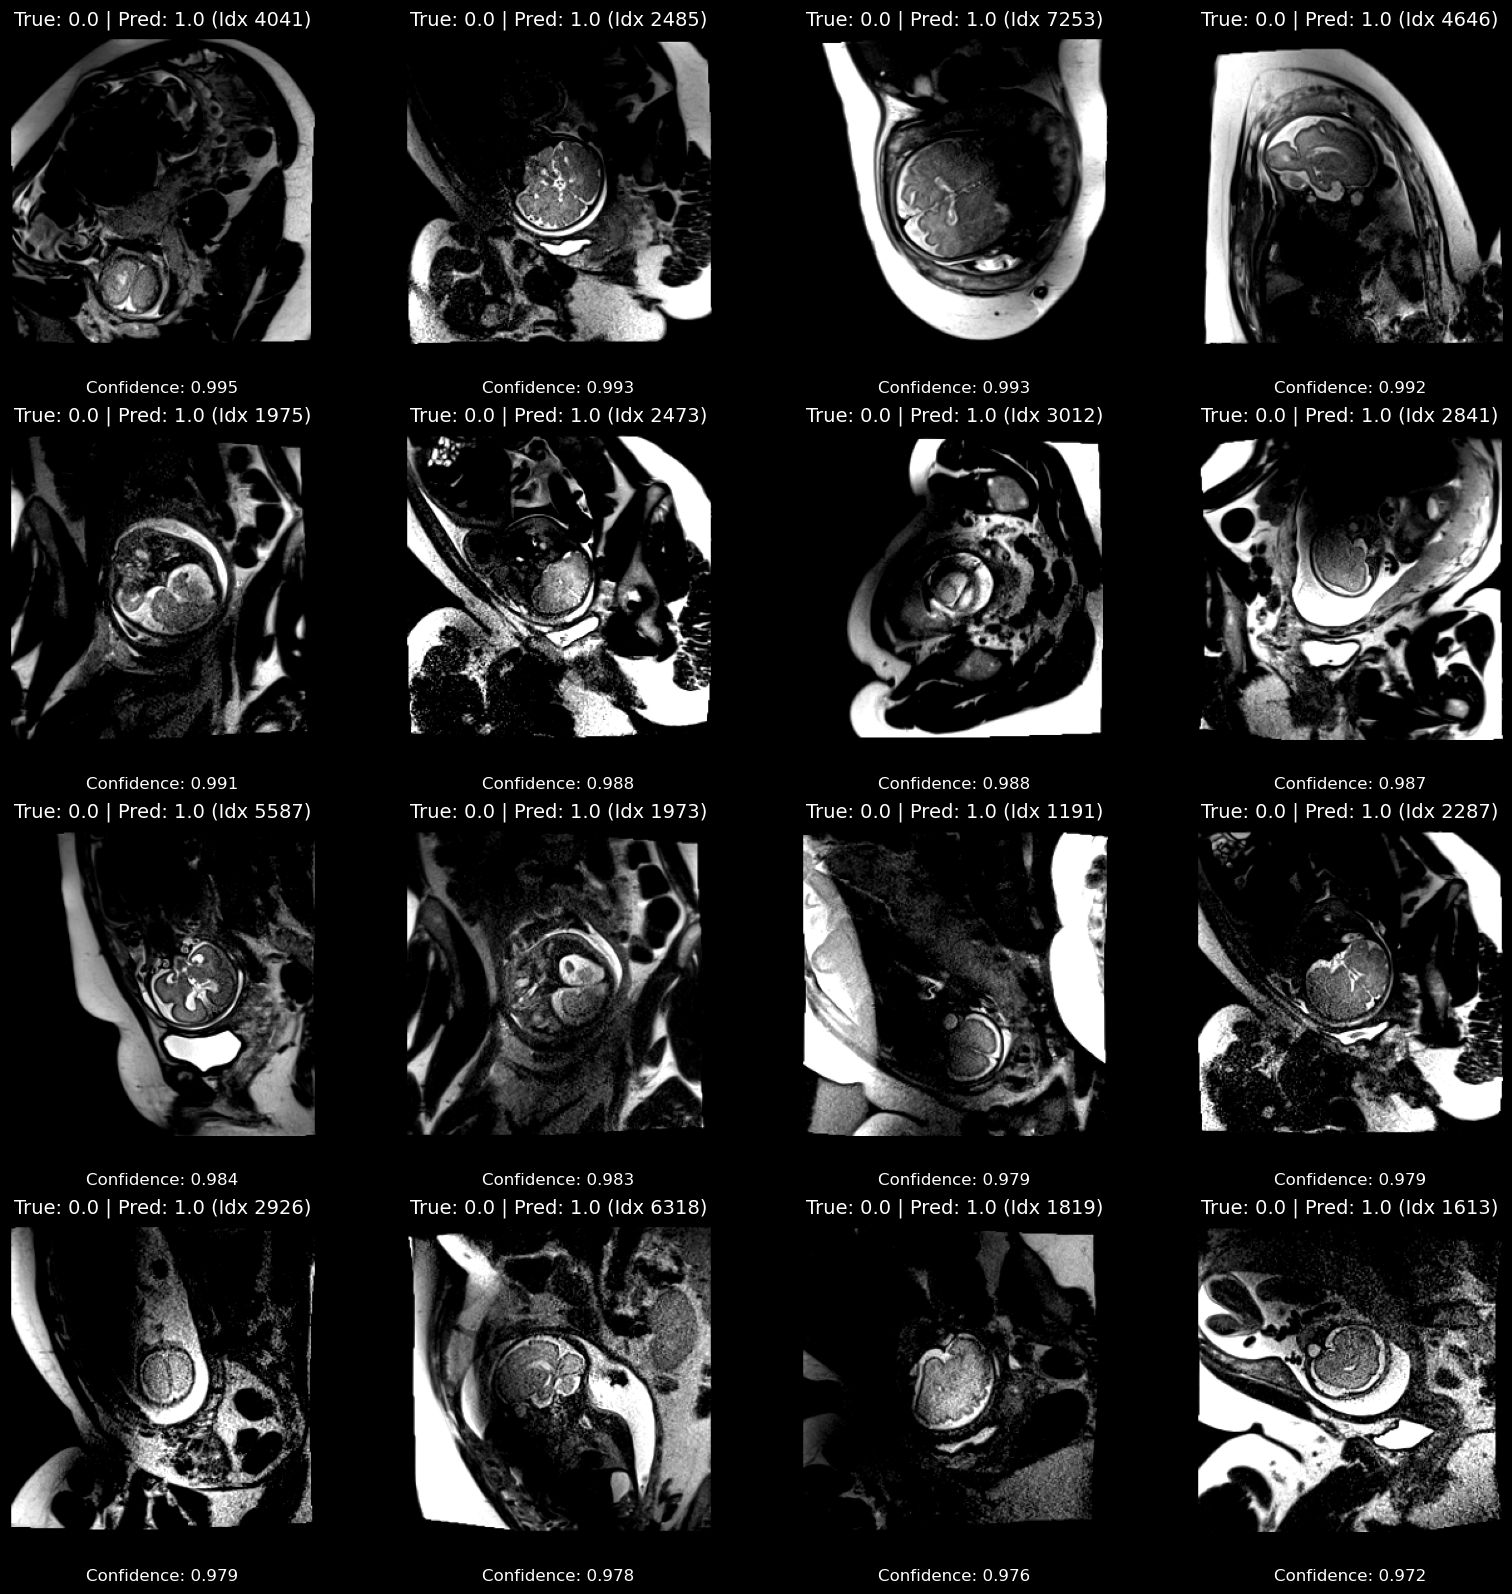

In [78]:
display_incorrect(incorrect_df[incorrect_df['pred'] == 1], dataset, max_display = 16)

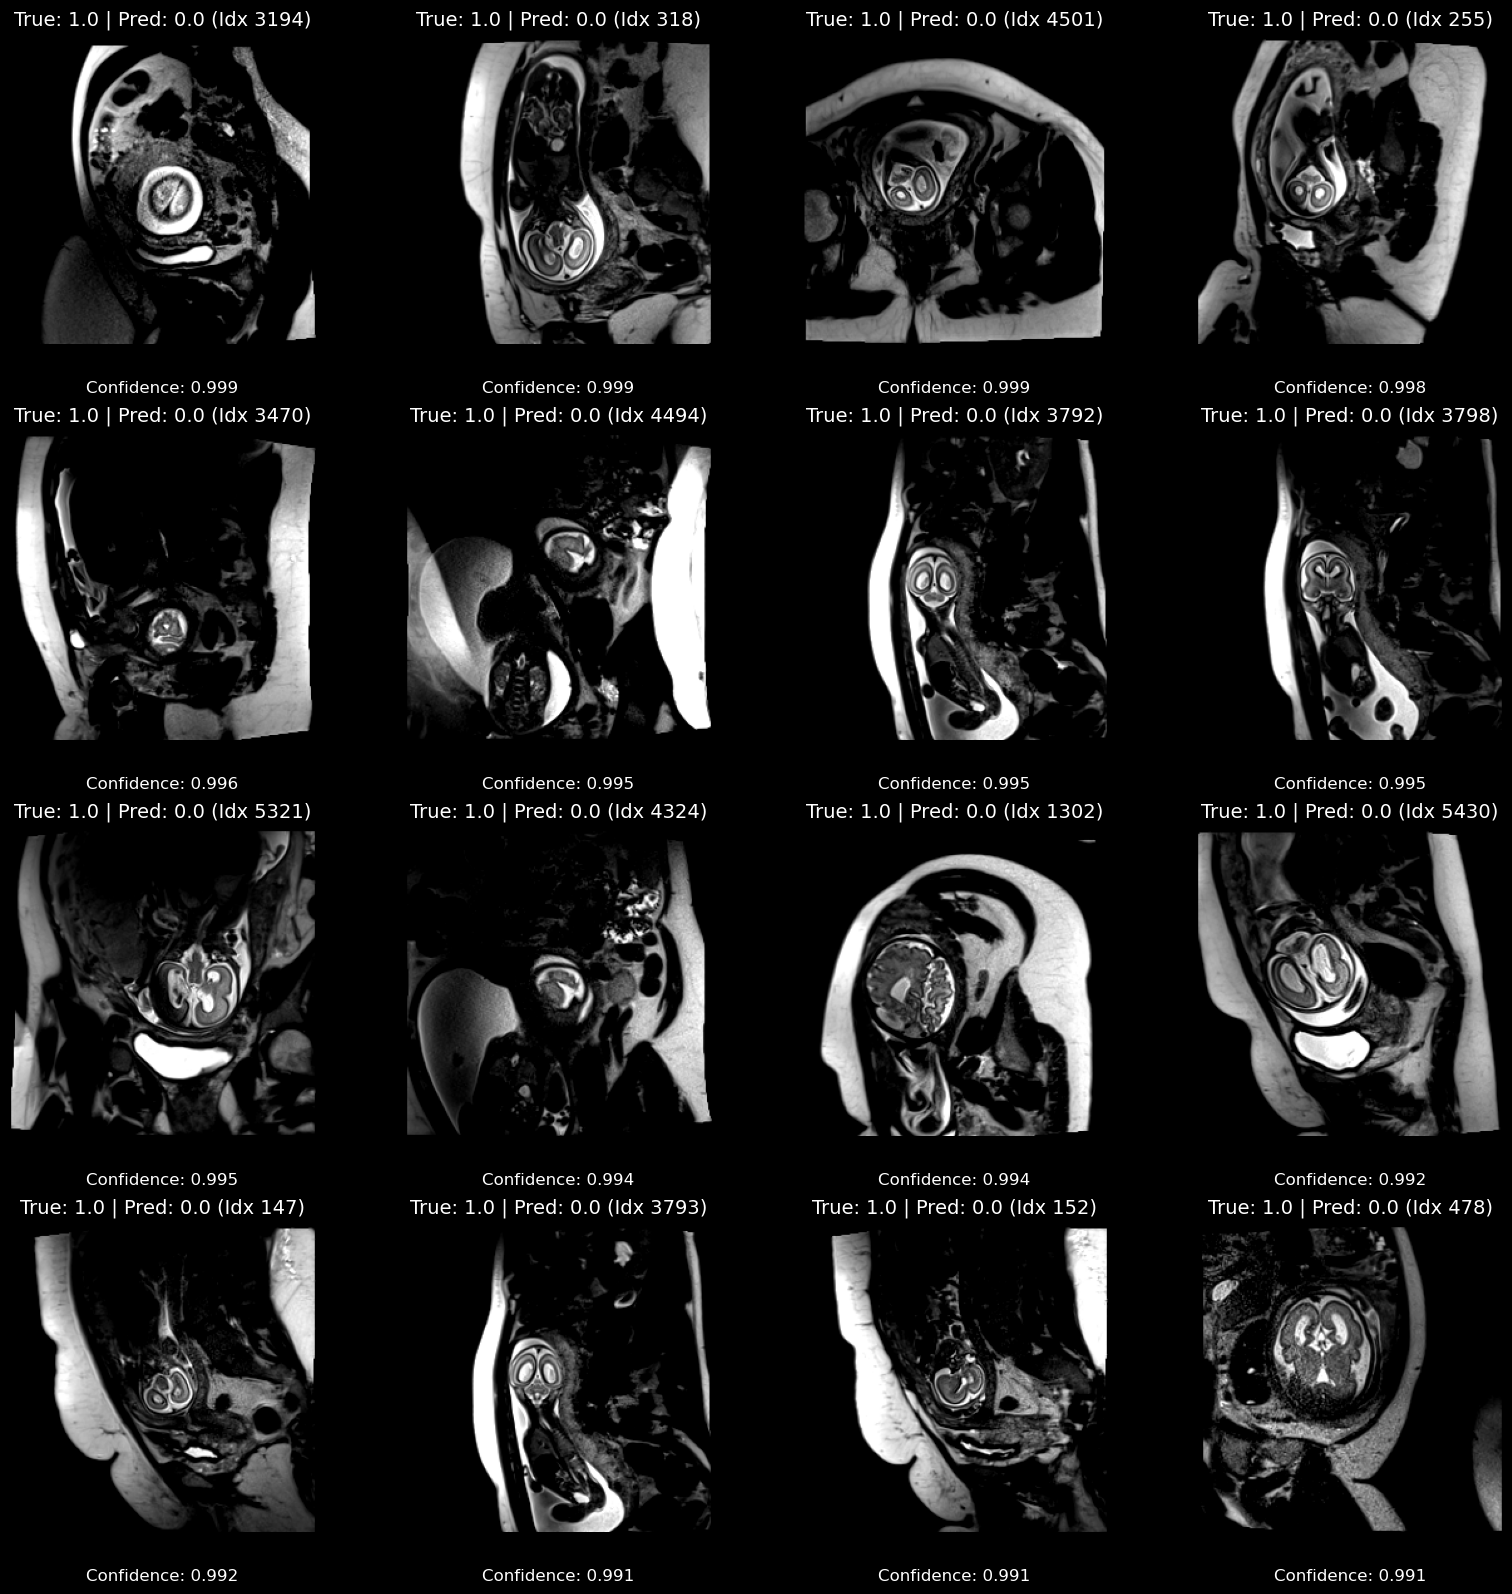

In [79]:
display_incorrect(incorrect_df[incorrect_df['pred'] == 0], dataset, max_display = 16)

<Axes: >

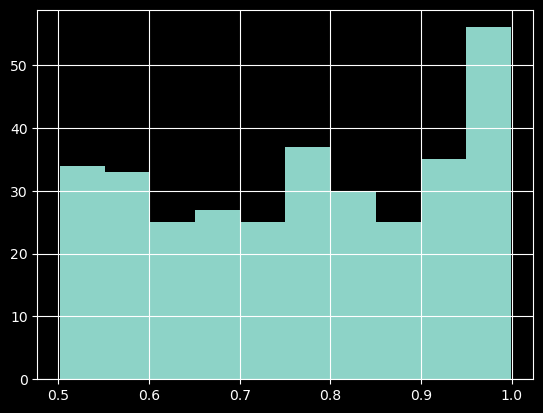

In [73]:
incorrect_df[incorrect_df['pred'] == 0]['conf'].hist()

<Axes: >

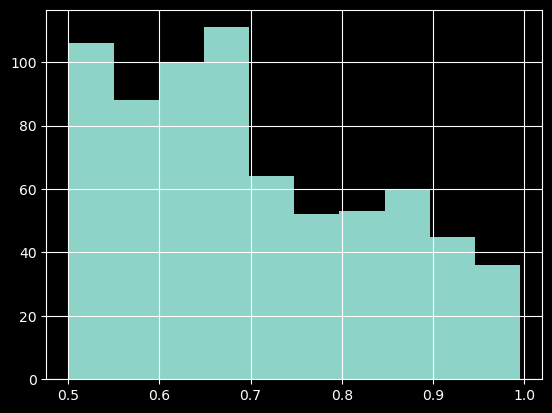

In [74]:
incorrect_df[incorrect_df['pred'] == 1]['conf'].hist()